In [ ]:
import math
import argparse
from tqdm import tqdm

import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import ToTensor
from sklearn.model_selection import train_test_split

from MAE.model import *
from src import dataset
from src import metrics
from src import configs as cfg
from MAE.utils import setup_seed

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


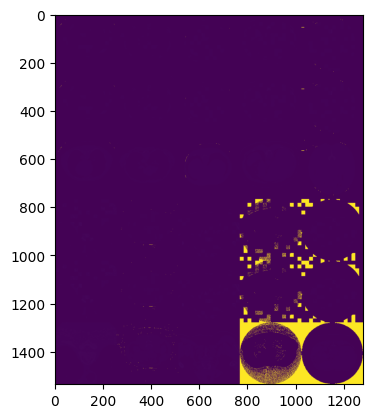

epoch   0: 17375.019421386718


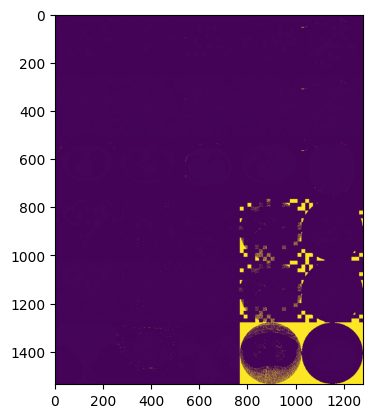

epoch   1: 17226.623864746092
epoch   2: 16733.068920898437
epoch   3: 15434.938122558593
epoch   4: 13751.843908691406
epoch   5: 12933.902526855469
epoch   6: 12289.356127929688
epoch   7: 11164.875158691406


KeyboardInterrupt: 

In [ ]:
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader):
    ''' visualize the first 16 predicted images on val dataset'''
    model.eval()
    with torch.no_grad():
        (x, ) = next(iter(data_loader))
        x = dataset.preprocess_imgs(x)
        x = x.to(device=cfg.DEVICE, dtype=torch.float)
        x = x.to(device)[:10]
        predicted_val_img, mask = model(x)
        predicted_val_img = predicted_val_img * mask + x * (1 - mask)
        img = torch.cat([x * (1 - mask), predicted_val_img, x], dim=0)
        img = rearrange(img, '(v h1 w1) c h w -> c (h1 h) (w1 v w)', w1=2, v=3)
        plt.imshow(img.detach().cpu().numpy().swapaxes(0, 2))
        plt.show()


max_lr=5e-4
mask_ratio=0.75
total_epoch=50
warmup_epoch=15

dataset.mk_dataset(verbose=False)
train_cfg = cfg.TrainingConfig(batch_size=64)
model_cfg = cfg.ModelConfig()
dataset_cfg = cfg.DatasetConfig()

setup_seed(train_cfg.random_state)
torch.backends.cuda.matmul.fp32_precision = 'ieee'
batch_size = load_batch_size = train_cfg.batch_size

x_train, y_train, x_test = dataset.load_raw_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=dataset_cfg.test_size,
    random_state=train_cfg.random_state,
)
train_tensor = torch.cat((x_train, x_test)).to(device="cuda")
train_ds = torch.utils.data.TensorDataset(train_tensor)
train_loader = torch.utils.data.DataLoader(
    train_ds,
    train_cfg.batch_size,
    shuffle=True,
)

model = MAE_ViT(
    image_size=256,
    mask_ratio=mask_ratio,
    patch_size=16,
    emb_dim=128,
    encoder_layer=6,
    encoder_head=8,
    decoder_head=8,
).to(cfg.DEVICE)
optim = torch.optim.AdamW(
    model.parameters(),
    lr=max_lr * batch_size / 256,
    betas=(0.9, 0.95),
)
def lr_func(epoch: int) -> float:
    return min(
        (epoch + 1) / (warmup_epoch + 1e-8),
        0.5 * (math.cos(epoch / total_epoch * math.pi) + 1)
    )
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda=lr_func)

eval_model(model, train_loader)
step_count = 0
for e in range(total_epoch):
    model.train()
    losses = []
    for (x,) in train_loader:
        x = dataset.preprocess_imgs(x)
        optim.zero_grad()
        step_count += 1
        with torch.autocast(cfg.DEVICE.type, torch.bfloat16):
            predicted_img, mask = model(x)
            loss = torch.mean((predicted_img - x) ** 2 * mask) / mask_ratio
        loss.backward()
        optim.step()
        losses.append(loss.item())
    lr_scheduler.step()
    avg_loss = sum(losses) / len(losses)
    print(f'epoch {e:3d}: {avg_loss}')
    ''' save model '''
    torch.save(model, "pretrained-vit.pt")
    if e % 20 == 0:
        eval_model(model, train_loader)